# PyTorch digit classification — GPU

This notebook is the GPU version of the earlier CPU PyTorch digits project.

The model architecture and dataset stay the same. The main difference is that the model and batches are moved to the NVIDIA GPU using CUDA so that the training workflow can be compared directly with the CPU version.


In [29]:
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)


## Check CUDA and select the GPU

Before training, verify that the current Jupyter kernel is using a CUDA-enabled PyTorch installation.


In [30]:
print("PyTorch version:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. Make sure this notebook is using the environment "
        "where the CUDA-enabled PyTorch build is installed."
    )

device = torch.device("cuda")

print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.14.0+cu130
CUDA build: 13.0
CUDA available: True
Using device: cuda
GPU: NVIDIA GeForce GTX 1650


## Load and prepare the digits dataset

We use the same `8 × 8` handwritten digit dataset and the same `80/20` stratified train/test split as in the CPU notebook. Pixel values are scaled from `0–16` to approximately `0–1`.


In [31]:
digits = load_digits()

X = digits.data
y = digits.target

print("Images shape:", digits.images.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", digits.target_names)


Images shape: (1797, 8, 8)
Feature matrix shape: (1797, 64)
Target shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train / 16.0
X_test = X_test / 16.0

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (1437, 64)
Test set: (360, 64)


In [33]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Number of training batches:", len(train_loader))


Number of training batches: 45


## Define and train the neural network on GPU

The network is unchanged from the CPU example. Calling `.to(device)` moves the model parameters to GPU memory, while each training batch is also moved to the GPU before the forward pass.


In [34]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


model = DigitClassifier().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)


DigitClassifier(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [35]:
epochs = 25
loss_history = []

torch.cuda.synchronize()
start_time = time.perf_counter()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} "
        f"- Loss: {epoch_loss:.4f}"
    )

torch.cuda.synchronize()
training_time = time.perf_counter() - start_time

print(f"\nGPU training time: {training_time:.4f} seconds")


Epoch 01/25 - Loss: 2.0922
Epoch 02/25 - Loss: 1.1518
Epoch 03/25 - Loss: 0.5232
Epoch 04/25 - Loss: 0.3363
Epoch 05/25 - Loss: 0.2498
Epoch 06/25 - Loss: 0.2037
Epoch 07/25 - Loss: 0.1675
Epoch 08/25 - Loss: 0.1450
Epoch 09/25 - Loss: 0.1286
Epoch 10/25 - Loss: 0.1152
Epoch 11/25 - Loss: 0.0979
Epoch 12/25 - Loss: 0.0902
Epoch 13/25 - Loss: 0.0902
Epoch 14/25 - Loss: 0.0830
Epoch 15/25 - Loss: 0.0722
Epoch 16/25 - Loss: 0.0658
Epoch 17/25 - Loss: 0.0596
Epoch 18/25 - Loss: 0.0589
Epoch 19/25 - Loss: 0.0501
Epoch 20/25 - Loss: 0.0461
Epoch 21/25 - Loss: 0.0442
Epoch 22/25 - Loss: 0.0400
Epoch 23/25 - Loss: 0.0396
Epoch 24/25 - Loss: 0.0368
Epoch 25/25 - Loss: 0.0359

GPU training time: 3.6667 seconds


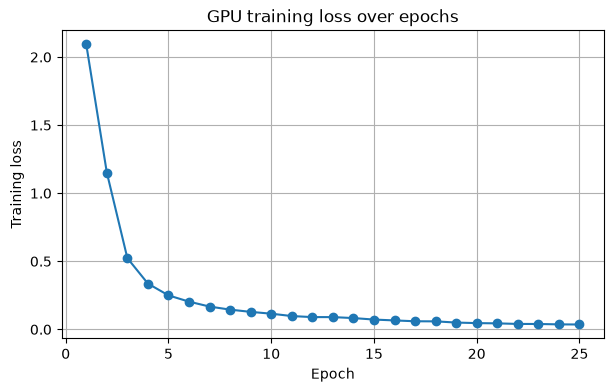

In [36]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("GPU training loss over epochs")
plt.grid(True)

plt.show()


## Evaluate the model

The test tensor is moved to the GPU for inference. Predictions are then moved back to CPU memory with `.cpu().numpy()` so they can be evaluated using scikit-learn.


In [37]:
model.eval()

with torch.no_grad():
    X_test_gpu = X_test_tensor.to(device)

    outputs = model(X_test_gpu)

    predicted = torch.argmax(
        outputs,
        dim=1
    )

predicted_np = predicted.cpu().numpy()

print("First 20 predictions:")
print(predicted_np[:20])

print("\nFirst 20 actual labels:")
print(y_test[:20])


First 20 predictions:
[5 2 8 1 7 2 6 2 6 5 0 5 9 3 4 4 2 4 9 9]

First 20 actual labels:
[5 2 8 1 7 2 6 2 6 5 0 5 9 3 4 4 2 4 9 9]


In [38]:
accuracy = accuracy_score(
    y_test,
    predicted_np
)

print(f"Test accuracy: {accuracy:.4f}")
print(f"Test accuracy: {accuracy * 100:.2f}%")


Test accuracy: 0.9722
Test accuracy: 97.22%


In [39]:
print(
    classification_report(
        y_test,
        predicted_np
    )
)


              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.90      0.97      0.93        36
           2       1.00      1.00      1.00        35
           3       1.00      0.97      0.99        37
           4       0.97      0.97      0.97        36
           5       0.97      1.00      0.99        37
           6       0.97      0.97      0.97        36
           7       0.97      1.00      0.99        36
           8       0.94      0.89      0.91        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



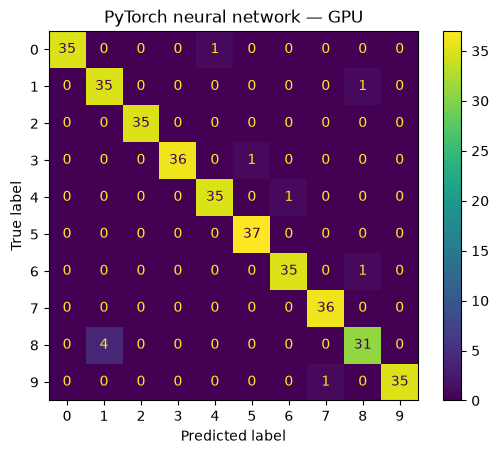

In [40]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicted_np
)

plt.title("PyTorch neural network — GPU")
plt.show()


## Inspect misclassified images and GPU memory

The final cells inspect some incorrect predictions and show the approximate amount of GPU memory currently allocated and reserved by PyTorch.


Number of misclassified samples: 10


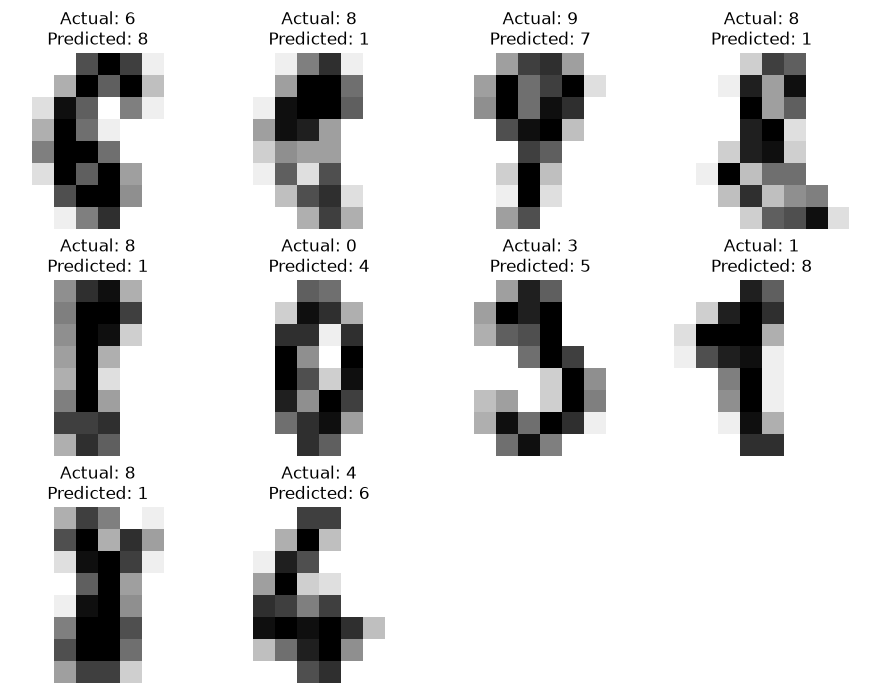

In [41]:
wrong_indices = np.where(
    predicted_np != y_test
)[0]

print("Number of misclassified samples:", len(wrong_indices))

num_to_show = min(12, len(wrong_indices))

fig, axes = plt.subplots(3, 4, figsize=(9, 7))

for ax, idx in zip(
    axes.ravel(),
    wrong_indices[:num_to_show]
):
    ax.imshow(
        X_test[idx].reshape(8, 8),
        cmap="gray_r"
    )

    ax.set_title(
        f"Actual: {y_test[idx]}\n"
        f"Predicted: {predicted_np[idx]}"
    )

    ax.axis("off")

for ax in axes.ravel()[num_to_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [42]:
print("GPU memory allocated:",
      f"{torch.cuda.memory_allocated() / 1024**2:.2f} MB")

print("GPU memory reserved:",
      f"{torch.cuda.memory_reserved() / 1024**2:.2f} MB")


GPU memory allocated: 16.63 MB
GPU memory reserved: 22.00 MB


## Summary

This notebook keeps the same neural-network problem as the CPU version and changes only the execution device.

The main GPU-specific additions are:

`model.to("cuda")`  
`batch.to("cuda")`  
`prediction.cpu().numpy()`  
`torch.cuda.synchronize()` for reliable timing
